In [ ]:
# Preparo las librerías que voy a necesitar. Incluyo Sklearn y stats model para explorar los modelos desde ambas.

import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import kagglehub
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder as ohe, LabelEncoder as le
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from collections import defaultdict

seed = 333

In [ ]:
# Descargo la base de datos desde Kaggle

path = kagglehub.dataset_download("yasserh/titanic-dataset")
print(path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
/kaggle/input/titanic-dataset


In [ ]:
# Abro el dataset

df = pd.read_csv(os.path.join(path,"/kaggle/input/titanic-dataset/Titanic-Dataset.csv"))
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
# Hago un análisis preliminar del tamaño del dataset, los nombres de las variables y el tipo de dato que contienen.

print(f"N Filas y columnas: \n{df.shape}\n\nTipos de variable: \n{df.dtypes}\n\nLista de variables:\n{df.columns}")

N Filas y columnas: 
(891, 12)

Tipos de variable: 
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Lista de variables:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [ ]:
# Examino si hay valores perdidos.

df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [ ]:
# Calculo variables FamilySize, IsAlone, CabinYesNo y Title
df1 = df.copy()
df1['FamilySize'] = df1['Parch'] + df1['SibSp'] + 1
df1['IsAlone'] = (df1['FamilySize'] == 1).astype(int)
df1['CabinYesNo'] = df1['Cabin'].notnull().astype(int)
df1['Title'] = df1['Name'].str.extract(r',\s*([A-Za-z]+)\.?')
df1['Title'] = df1['Name'].str.extract(r',\s*(.+?)\.')
df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,CabinYesNo,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,1,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,1,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,0,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,1,0,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,1,1,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,0,0,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,1,1,Mr


In [ ]:
# Reviso los valores de Name y recodifico en cinco categorías (Mr, Miss, Mrs, Master, Others)

print(f"Antes de mapear {df1['Title'].value_counts()}\n\nMissings: {df1['Title'].isnull().sum()}\n")

title_mapping = {'Mlle': 'Miss',
                 'Mme': 'Mrs',
                 'Dr':'Others',
                 'Rev':'Others',
                 'Major':'Others',
                 'Col':'Others',
                 'Capt':'Others',
                 'Don':'Others',
                 'Sir':'Others',
                 'Jonkheer':'Others',
                 'Lady':'Others',
                 'Ms':'Others',
                 'the Countess': 'Others'}

df1['Title'] = df1['Title'].map(title_mapping).fillna(df1['Title'])

print(f"Después de mapear {df1['Title'].value_counts()}\n\nMissings: {df1['Title'].isnull().sum()}")

Antes de mapear Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Missings: 0

Después de mapear Title
Mr        517
Miss      184
Mrs       126
Master     40
Others     24
Name: count, dtype: int64

Missings: 0


In [ ]:
print(f"N Filas y columnas: \n{df1.shape}\n\nTipos de variable: \n{df1.dtypes}\n\nLista de variables:\n{df1.columns}")

N Filas y columnas: 
(891, 16)

Tipos de variable: 
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
FamilySize       int64
IsAlone          int64
CabinYesNo       int64
Title           object
dtype: object

Lista de variables:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone',
       'CabinYesNo', 'Title'],
      dtype='object')


In [ ]:
# Examino el rango de valores de las variables.

print(f"Variables numéricas: \n \n{df.describe()}")
print()
print(f"Variables categóricas/de cadena: \n\n{df['Sex'].value_counts()},\n\n{df['Cabin'].value_counts()},\n\n{df['Embarked'].value_counts()}")

Variables numéricas: 
 
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Variables categóricas/de cadena: 

Sex
male      577
fem

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>,
        <Axes: title={'center': 'FamilySize'}>,
        <Axes: title={'center': 'IsAlone'}>],
       [<Axes: title={'center': 'CabinYesNo'}>, <Axes: >, <Axes: >]],
      dtype=object)

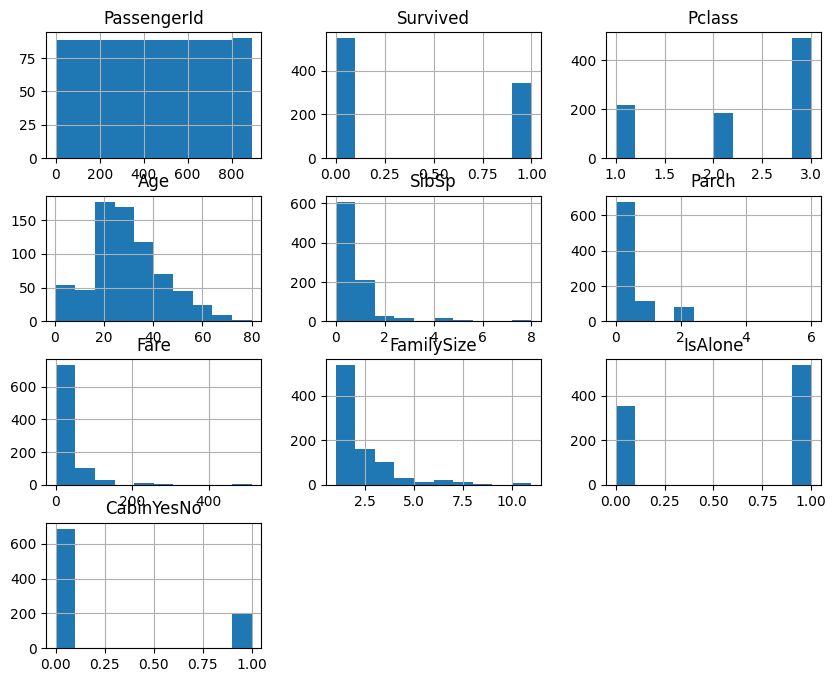

In [ ]:
# Examino las distribuciones de los valores de las variables.

df1.hist(figsize=(10,8))

<Axes: xlabel='Sex'>

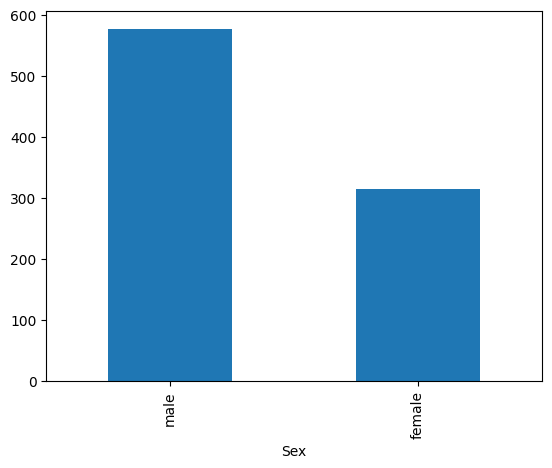

In [ ]:
df['Sex'].value_counts().plot(kind='bar')

<Axes: xlabel='Embarked'>

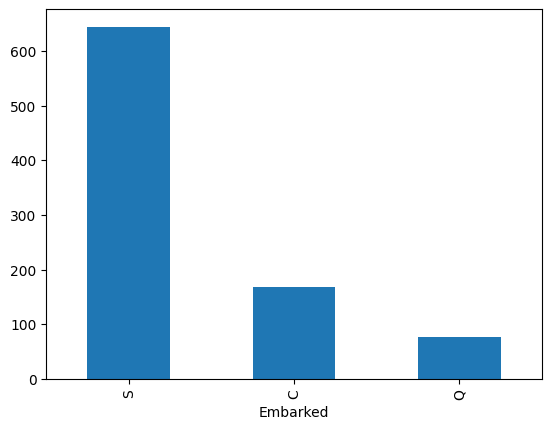

In [ ]:
df['Embarked'].value_counts().plot(kind='bar')

In [ ]:
train['Sex_encoded'] = le.fit_transform(train['Sex'])

# Aplicar la misma transformación aprendida a test (sin volver a "fit")
test['Sex_encoded'] = le.transform(test['Sex'])

In [ ]:
x_train = train.drop(columns=["Survived"])
y_train=train["Survived"]

In [ ]:
X = x_train.select_dtypes(include=[np.number])
X = sm.add_constant(X, has_constant="add")
y = y_train.astype(float).copy()

model = sm.Logit(y, X)
results = model.fit(method="lbfgs",maxiter=1000,disp=True)

print(results.summary())

In [ ]:
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
encoder.fit(train[['Embarked']])  # aprende categorías SOLO de train

In [ ]:
from sklearn.ensemble import RandomForestClassifier

y = train_data["Survived"]

features = ["Pclass", "Sex", "SibSp", "Parch"]
X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X, y)
predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)